<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/06_compensated_mahalanobis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 146 (delta 73), reused 82 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (146/146), 7.90 MiB | 25.12 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 — config, load Step 5's trained CNN, rebuild the no-shift reference covariance
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from src.channel import SignalConfig, generate_soi, generate_noise, apply_time_shift, mix_signal
from src.data_loader import make_clean_sample, build_test_set
from src.model import (estimate_covariance, mahalanobis_score, TimeShiftCNN,
                        estimate_frequency_shift, compensate_signal, complex_to_channels)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# BASE-PAPER FACT: real fd_max=200Hz (unlike Steps 3/4 which forced fd_max=0 for the easy case)
cfg = SignalConfig(fd_max=200.0)
rng = np.random.default_rng(42)
N_SYMBOLS = 64
SIR_DB, SNR_DB = 20.0, 15.0  # BASE-PAPER FACT (consistent condition throughout)

# Load Step 5's CNN
timeshift_model = TimeShiftCNN(cfg.NSPS).to(device)
timeshift_model.load_state_dict(torch.load("checkpoints/timeshift_cnn.pt", map_location=device))
timeshift_model.eval()
print("CNN loaded.")

# Rebuild reference covariance under NO-SHIFT condition (this is what "compensated" signals get scored against)
cfg_noshift = SignalConfig(fd_max=0.0)
M_TRAIN = 4000
clean_ref = [make_clean_sample(cfg_noshift, N_SYMBOLS, SNR_DB, rng) for _ in range(M_TRAIN)]
C_ref = estimate_covariance(clean_ref)
C_ref_inv = np.linalg.inv(C_ref)
print("Reference covariance ready.")

CNN loaded.
Reference covariance ready.


In [3]:
# Cell 3 — build test set WITH both shifts active (Table 1's hardest condition)
def build_shifted_test_set(cfg, n_symbols, rng, interference_type, n_test, sir_db, snr_db):
    samples, labels = [], []
    for _ in range(n_test):
        d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type,
                        contamination=0.5, sir_db_range=(sir_db, sir_db),
                        snr_db_range=(snr_db, snr_db),
                        apply_shift=True)  # KEY DIFFERENCE from Step 3/4: shift is now active
        samples.append(d["x"]); labels.append(d["label"])
    return samples, np.array(labels, dtype=int)

In [4]:
# Cell 4 — raw (uncompensated) Mahalanobis on shifted signals -- expect degradation
paper_raw_shifted = {"tone": 0.593, "chirp": 0.5999, "fawgn": 0.5973}  # BASE-PAPER FACT (Table 1, Yes/Yes row)

raw_results = {}
for itype in ["tone", "chirp", "fawgn"]:
    samples, labels = build_shifted_test_set(cfg, N_SYMBOLS, rng, itype, 200, SIR_DB, SNR_DB)
    scores = [mahalanobis_score(x, C_ref_inv) for x in samples]
    auc = roc_auc_score(labels, scores)
    raw_results[itype] = auc
    print(f"{itype:6s}  RAW Mahalanobis AUC={auc:.4f}   paper (Table1, Yes/Yes)={paper_raw_shifted[itype]:.4f}")

tone    RAW Mahalanobis AUC=0.5437   paper (Table1, Yes/Yes)=0.5930
chirp   RAW Mahalanobis AUC=0.4871   paper (Table1, Yes/Yes)=0.5999
fawgn   RAW Mahalanobis AUC=0.5433   paper (Table1, Yes/Yes)=0.5973


In [5]:
# Cell 5 — compensated Mahalanobis on the SAME shifted signals
compensated_results = {}
fd_estimates, k_estimates = {}, {}

for itype in ["tone", "chirp", "fawgn"]:
    samples, labels = build_shifted_test_set(cfg, N_SYMBOLS, rng, itype, 200, SIR_DB, SNR_DB)
    scores, fds, ks = [], [], []
    for x in samples:
        x_corr, fd_hat, k_hat = compensate_signal(x, cfg, timeshift_model, device)
        scores.append(mahalanobis_score(x_corr, C_ref_inv))
        fds.append(fd_hat); ks.append(k_hat)
    auc = roc_auc_score(labels, scores)
    compensated_results[itype] = auc
    fd_estimates[itype] = fds; k_estimates[itype] = ks
    print(f"{itype:6s}  COMPENSATED Mahalanobis AUC={auc:.4f}")

tone    COMPENSATED Mahalanobis AUC=0.8827
chirp   COMPENSATED Mahalanobis AUC=0.8641
fawgn   COMPENSATED Mahalanobis AUC=0.9864


       paper_raw_mahalanobis_auc  our_raw_auc  our_compensated_auc  \
tone                      0.5930     0.543657             0.882725   
chirp                     0.5999     0.487053             0.864143   
fawgn                     0.5973     0.543300             0.986395   

       compensation_gain  
tone            0.339068  
chirp           0.377090  
fawgn           0.443095  


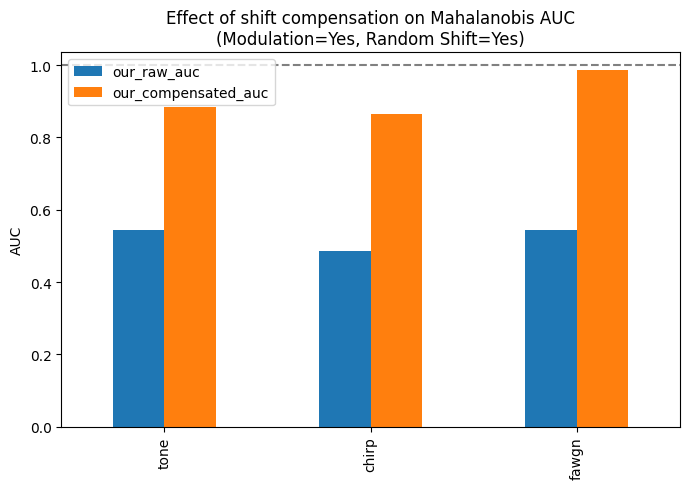

In [6]:
# Cell 6 — comparison table + plot
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "paper_raw_mahalanobis_auc": paper_raw_shifted,
    "our_raw_auc": raw_results,
    "our_compensated_auc": compensated_results,
})
comparison["compensation_gain"] = comparison["our_compensated_auc"] - comparison["our_raw_auc"]
print(comparison)
comparison.to_csv("results/step6_compensation_comparison.csv")

comparison[["our_raw_auc", "our_compensated_auc"]].plot(kind="bar", figsize=(7,5))
plt.axhline(1.0, linestyle="--", color="gray")
plt.ylabel("AUC")
plt.title("Effect of shift compensation on Mahalanobis AUC\n(Modulation=Yes, Random Shift=Yes)")
plt.tight_layout()
plt.savefig("figures/step6_compensation_comparison.png", dpi=150)
plt.show()